In [36]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetLanguage
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot
import OptimalBattery.estimate as et
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import SUITPy as suit
import OptimalBattery.simulate as sim
import nitools as nt


In [5]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
device = 'cuda' if pt.cuda.is_available() else 'cpu'

subj= None

In [6]:
MDTB_dataset = DataSetLanguage(f'{func_fus_dir}/Language')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondRun',subj=subj)
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondAll',subj=subj)
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0

# remove any spaces in the taskName column
info_mdtb_1_run['taskName'] = info_mdtb_1_run['taskName'].str.replace(' ', '')
info_mdtb_1_all['taskName'] = info_mdtb_1_all['taskName'].str.replace(' ', '')

data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='taskName',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='taskName',center_condition='rest')

task_names_s1  = info_mdtb_1_all['taskName'].unique()

In [7]:
def get_condition_indices(df):
    """
    Get condition indices from a dataframe and record the duration of each condition
    Parameters:
        df(pd.DataFrame): dataframe containing condition indices needs to include:
            - 'cond_name': name of the condition
            - 'run': run number
            - 'task_name': name of the task
    Returns:
        condition_indices(np.ndarray): condition indices
    """
    unique_conditions = df['taskName'].unique()
    new_df = pd.DataFrame(columns=['taskName', 'indices', 'duration'])
    
    # Filter only the first run
    first_run_df = df[df['run'] == df['run'].min()]
    task_run_counts = first_run_df.groupby('taskName')['taskName'].nunique()
    duration_map = {1: 30, 2: 15, 3: 10}
    
    # Populate the new dataframe
    for condition in unique_conditions:
        indices = df[df['taskName'] == condition].index.tolist()
        
        # Identify task_name for the condition from the original dataframe
        task_name = df[df['taskName'] == condition]['taskName'].values[0]
        num_conditions = task_run_counts.get(task_name, 1)
        duration = duration_map.get(num_conditions, 30)
        
        new_row = {'taskName': condition, 'indices': indices, 'duration': duration}
        new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)
    
    return new_df


In [8]:
condition_df= get_condition_indices(info_mdtb_1_run)


In [9]:
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation_32 = atlas.read_data(model_name)

region_mapping = {
    (1, 2, 3, 4): 1,
    (5, 6, 7): 2,
    (8, 9, 10, 11): 3,
    (12, 13, 14, 15, 16): 4,
    (17, 18, 19, 20): 5,  
    (21, 22, 23): 6,
    (24, 25, 26, 27): 7,
    (28, 29, 30, 31, 32): 8
}


flat_mapping = {k: v for keys, v in region_mapping.items() for k in keys}

# Vectorized mapping function
parcelation_8 = np.vectorize(lambda x: flat_mapping.get(int(x), x))(parcelation_32)

In [45]:
# params
ROI_to_include = [17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
ROI_to_include = np.arange(8)+1
ROI_mask = np.isin(parcelation_8, ROI_to_include).astype(int)
ROI_indices = np.where(ROI_mask == 1)[0]

cerebellum_mask  = np.ones_like(parcelation_32)
cerebellum_indices = np.where(cerebellum_mask == 1)[0]



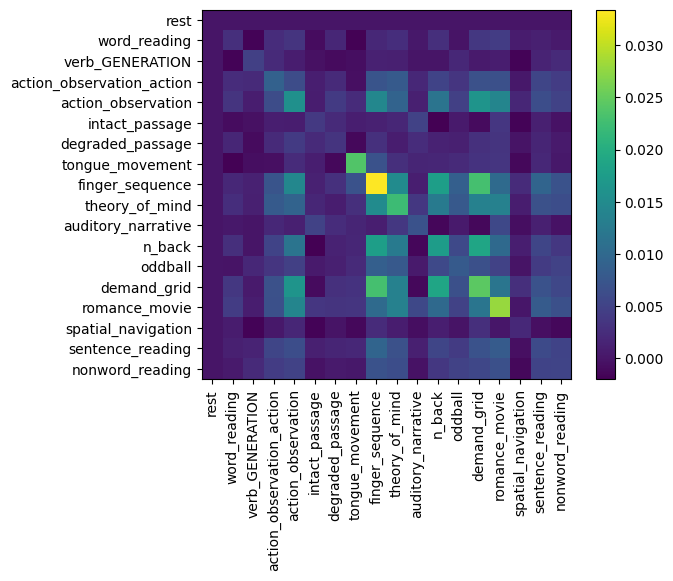

In [46]:
# Get G Lib
G_Lib = ct.get_G(data=data_mdtb_s1_run[:,:,ROI_indices],n_cond=18,n_part=8)
plt.imshow(G_Lib)
plt.xticks(np.arange(0, 18, 1), task_names_s1, rotation=90)
plt.yticks(np.arange(0, 18, 1), task_names_s1)
plt.colorbar()
plt.show()

In [47]:
# make variables torch
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation_8, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)

# estimate Vs for training using s2 full data
full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)


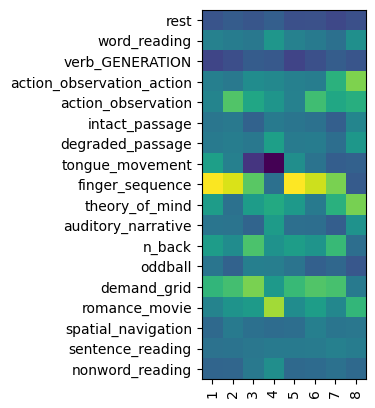

In [48]:
plt.imshow(full_vs_train.cpu().numpy())
plt.xticks(np.arange(0,full_vs_train.shape[1] ,1), np.arange(full_vs_train.shape[1])+1, rotation=90)
plt.yticks(np.arange(0,18 ,1), task_names_s1)
plt.show()

In [49]:
D = ct.build_combinations(G_Lib, strategy='random',n_batteries=40000,n_tasks=5,seed = 1,replacement=False,rest_idx= 0)
D_best = ct.choose_combination(D,'log_det_mc')
top_comb = D_best['combination'].values[0]
top_comb_list = list(top_comb)
print(f"Top combination: {task_names_s1[top_comb_list]}")

# get the regressors for training data
combination_regressors = ct.build_combination_regressors(top_comb, condition_df=condition_df, localizer_time=8)

# average, center and normalize the data used for the parcellation
Ysubset = ct.average_regressors(data_train, combination_regressors)
Ysubset = ut.center_matrix(Ysubset, axis=1)
Ysubset = ut.normalize_matrix(Ysubset, axis=1)

Vsubset = full_vs_train[top_comb,:]
Vsubset = ut.center_matrix(Vsubset, axis=0)
Vsubset = ut.normalize_matrix(Vsubset, axis=0)

Uhats =  et.estimate_Us(Ysubset, Vsubset, method='correlation',hard=True)



Top combination: ['tongue_movement' 'finger_sequence' 'theory_of_mind' 'romance_movie'
 'rest']


In [50]:
_, cmap, labels = nt.read_lut(f'{func_fus_dir}/Atlases/tpl-SUIT/atl-NettekovenSym32.lut')

In [51]:
Uhats_arg  = pt.argmax(Uhats, dim=1)  # shape: (17, 6000)

# If you want 1-based indexing instead of 0-based:
Uhats_arg= Uhats_arg + 1

# insure its int32 type
Uhats_arg = pt.tensor(Uhats_arg, dtype=pt.int32, device=device)

c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


In [52]:
Uhats_arg.shape

torch.Size([17, 6918])

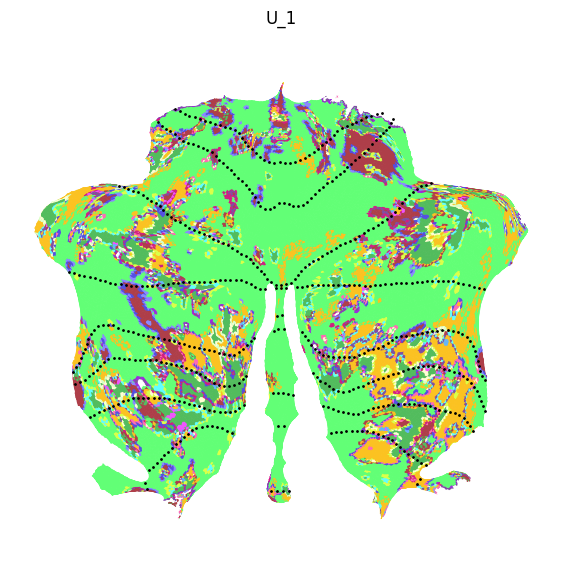

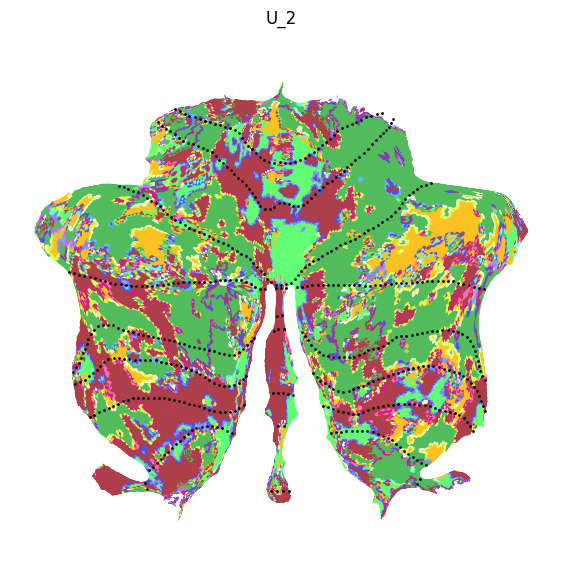

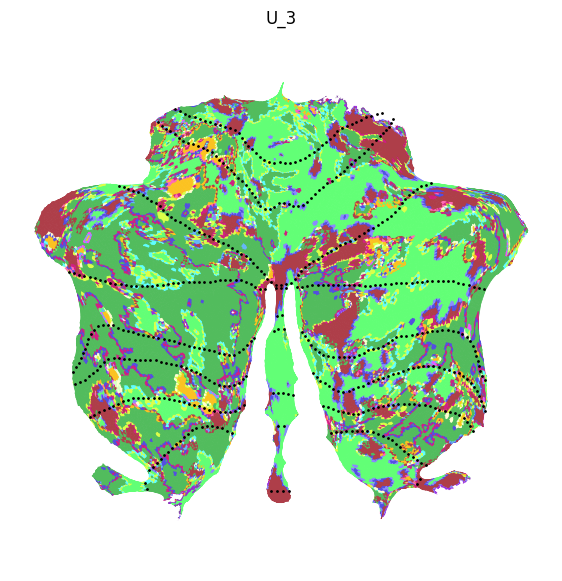

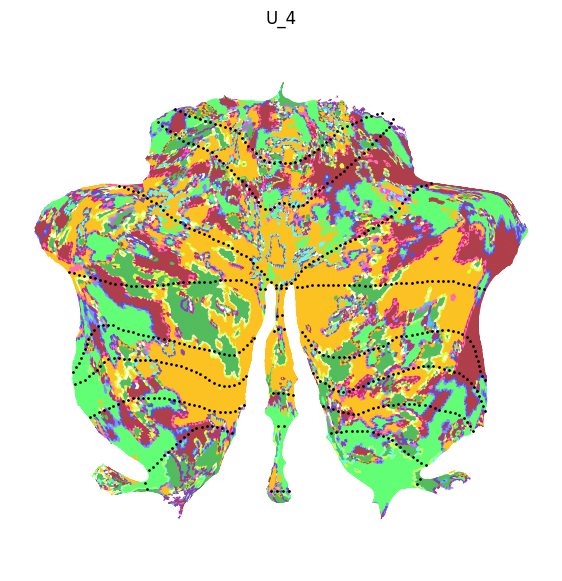

In [53]:
for i in range(4):
    img = atlas.data_to_nifti(Uhats_arg[i].cpu().numpy())
    surf = suit.flatmap.vol_to_surf(img,stats='mode')
    suit.plot(surf,cmap = cmap)
    plt.title(f"U_{i+1}")